In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# to soppress latex sintaxwarnings
import warnings
warnings.filterwarnings("ignore")

## Exercise 01.1

### Radius mean value


Below are reported the calculations of radius and variance obtained using $10^6$ step divided in 100 blocks


Here the implementation of the mean radius calculation and it's error:

```C++

vector<double> ave (N, 0); //averages on blocks
vector<double> av2 (N, 0); //averages squared on blocks

vector<double> sum_prog (N, 0);
vector<double> su2_prog (N, 0);
vector<double> err_prog (N, 0);

for(int i=0; i<N; ++i) //iterate on blocks
{
    float sum1=0; 
    for(int j=0; j<L; ++j) //iterate inside block
    {
        //generate along uniform distribution
        float r=rnd.Rannyu();
        sum1+=r;	      
    }
    ave[i] = sum1/L; //average on block
    av2[i]=pow(ave[i], 2); 		
}

for(int i=0; i<N; ++i)
{
    for(int j=0; j<=i; ++j)
    {
        sum_prog[i]+=ave[j]; // sum j=0,i r_j
        su2_prog[i]+=av2[j]; // sum j=0,i (r_j)^2
    }

    sum_prog[i]/=(i+1);
    su2_prog[i]/=(i+1);
    err_prog[i] = error(sum_prog, su2_prog, i);
}


```

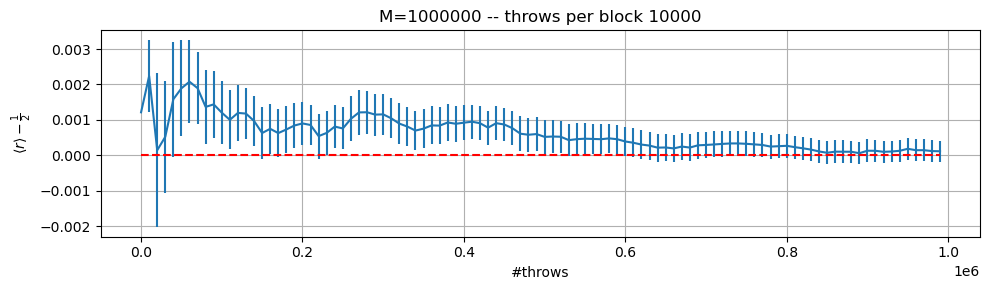

In [46]:
fig, ax = plt.subplots(1, 1,figsize=(10, 3))
n=0
for el in (os.listdir('data')):
    if ('data' not in el):
        continue
    if ('.csv'  not in el) or ('M' not in el):
        continue
    M=int(el.split('M')[1].split('.')[0])
        
    df=pd.read_csv('data/'+el)
    ax.set_title(f'M={M} -- throws per block {M//100}')
    
    ax.errorbar(
        df.throws, df.avg-0.5,
        yerr=df.err, 
    )

    # expected value
    ax.hlines(0, 0, df.throws[len(df)-1]+1, ls='--', colors='r')
    ax.set_xlabel('#throws')
    ax.set_ylabel(r'$\langle r \rangle-\frac{1}{2}$')
    ax.grid(True)
    n+=1
plt.tight_layout()
plt.show()

### Variance 

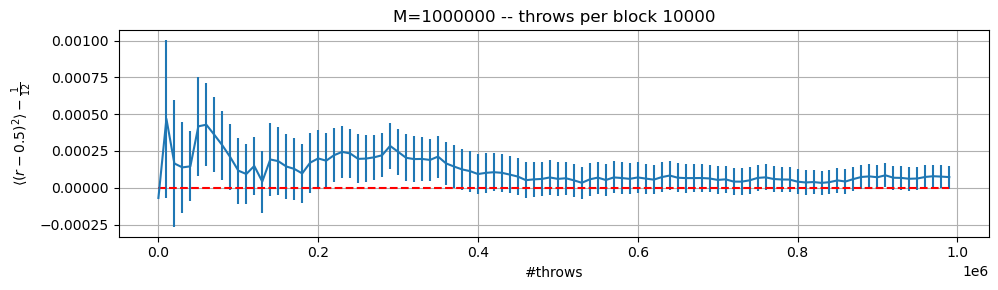

In [47]:
fig, ax = plt.subplots(1, 1,figsize=(10, 3))
n=0
for el in (os.listdir('data')):
    if ('var_estimation' not in el):
        continue
    if ('.csv'  not in el) or ('M' not in el):
        continue
    M=int(el.split('M')[1].split('.')[0])
        
    df=pd.read_csv('data/'+el)
    ax.set_title(f'M={M} -- throws per block {M//100}')
    
    ax.errorbar(
        df.throws, df.avg-1/12,
        yerr=df.err, 
    )

    # expected value
    ax.hlines(0, 0, df.throws[len(df)-1]+1, ls='--', colors='r')
    ax.set_xlabel('#throws')
    ax.set_ylabel(r'$\langle (r-0.5)^2 \rangle-\frac{1}{12}$')
    ax.grid(True)
    n+=1
plt.tight_layout()
plt.show()

both the radius and the variance converge at a value whom distance from the actual value is less than one standard deviation

# $\chi^2$

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df=pd.read_csv('data/chi2.csv')

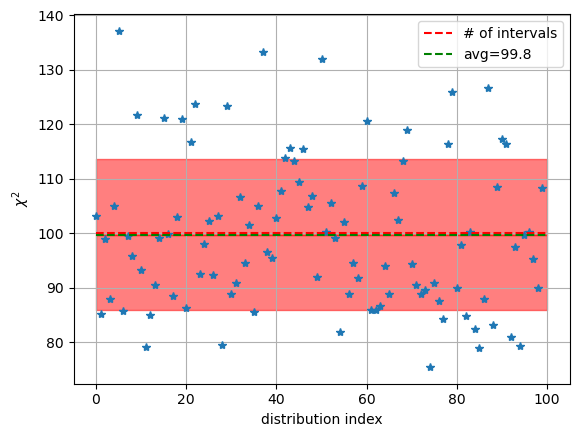

In [71]:

plt.plot(df.data, '*')
plt.hlines(
    100, 0, len(df),
    ls='--', colors='r', 
    label='# of intervals'
)

plt.hlines(
    df.data.mean(), 0, len(df), 
    ls='--', colors='g', 
    label=f'avg={"%.1f"%df.data.mean()}'
)

plt.fill_between(
    range(0,101), 
    df.data.mean(), 
    df.data.mean()+np.sqrt(df.data.var()),
    color='r', alpha=0.5
)
plt.fill_between(
    range(0,101), 
    df.data.mean(), 
    df.data.mean()-np.sqrt(df.data.var()),
    color='r', alpha=0.5
)


plt.ylabel(r'$\chi^2$')
plt.xlabel('distribution index')
plt.grid(True)
plt.legend()
plt.show()

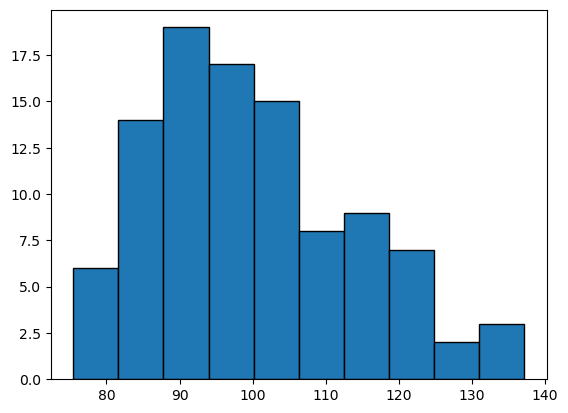

In [84]:
plt.hist(df.data, edgecolor='black', linewidth=1)
#lt.hlines(100, 0, len(df), ls='--', colors='r')

#$plt.ylabel(r'$\chi^2$')
#plt.xlabel('distribution index')
#plt.grid(True)
plt.show()

## Exercise 01.2

I implemented a new class RandomMod using inheritance from the old Random class

```C++

class RandomMod: public Random
{
	public:
		double exp(double lambda=1.);
		
		double CauchyLorentz(double mu=0., double gamma=1.);
};

```

For every cumulative distribution $S_N$ i created $10^4$ values of the sums (with a number of throws of $n*10^4$) so that the distributions had always the same number of points to produce the histograms


In [32]:
from scipy.optimize import curve_fit
import numpy as np

def gaussian(x, mu, sigma):
    return np.exp(-pow(x-mu, 2)/(2*sigma**2))/(np.sqrt(2*np.pi)*sigma)

## Exponential distribution

Below the implementation of the exponential generator

```C++
double RandomMod::exp(double lambda)
{
	double y=Rannyu();
	return -(1/lambda)*log(1-y);
}
```

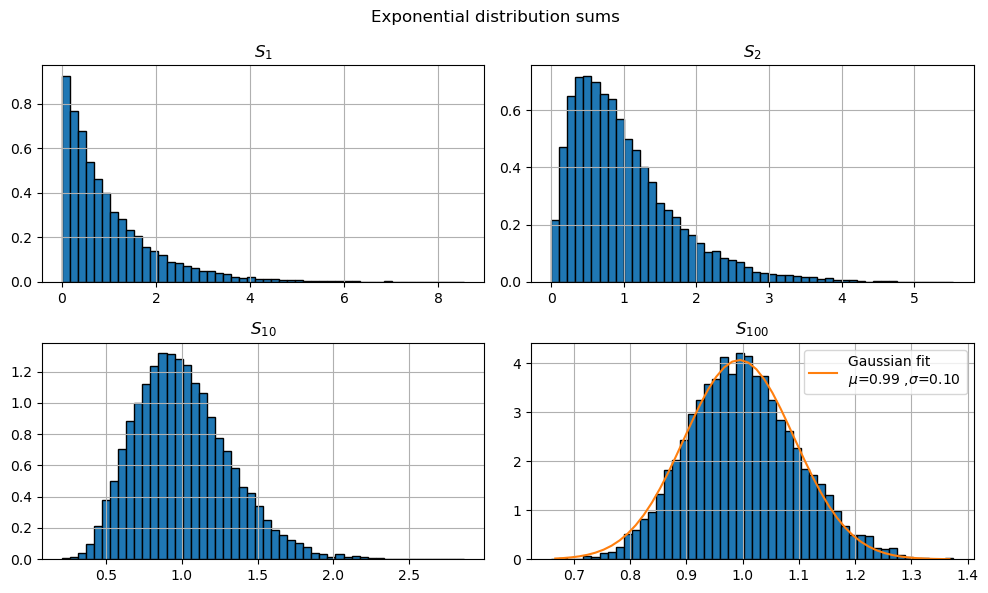

In [55]:
exp_N1=pd.read_csv('data/exp_N1.csv')
exp_N2=pd.read_csv('data/exp_N2.csv')
exp_N10=pd.read_csv('data/exp_N10.csv')
exp_N100=pd.read_csv('data/exp_N100.csv')

fig, ax = plt.subplots(2, 2, figsize=(10,6))
fig.suptitle('Exponential distribution sums')


ax[0, 0].hist(exp_N1.data,  bins=50, density=True, edgecolor='black', linewidth=1)
ax[0, 0].set_title('$S_1$')

ax[0, 1].hist(exp_N2.data,  bins=50, density=True, edgecolor='black', linewidth=1)
ax[0, 1].set_title('$S_2$')

ax[1, 0].hist(exp_N10.data, bins=50, density=True, edgecolor='black', linewidth=1)
ax[1, 0].set_title('$S_{10}$')

ax[1, 1].hist(exp_N100.data,bins=50, density=True, edgecolor='black', linewidth=1)
ax[1, 1].set_title('$S_{100}$')

y, bins = np.histogram(exp_N100.data, bins=50, density=True)
xc=[0.5*(bins[k]+bins[k+1]) for k in range(len(bins)-1)]

popt, pcov = curve_fit(gaussian, xc, y)
ax[1, 1].plot(xc, gaussian(xc, popt[0], popt[1]), label=f'Gaussian fit \n$\mu$={"%.2f"%popt[0]} ,$\sigma$={"%.2f"%popt[1]}')
ax[1, 1].legend()

for k in [0,1]:
    for j  in [0,1]:
        ax[k,j].grid(True)
plt.tight_layout()
plt.show()

## Uniform distribution

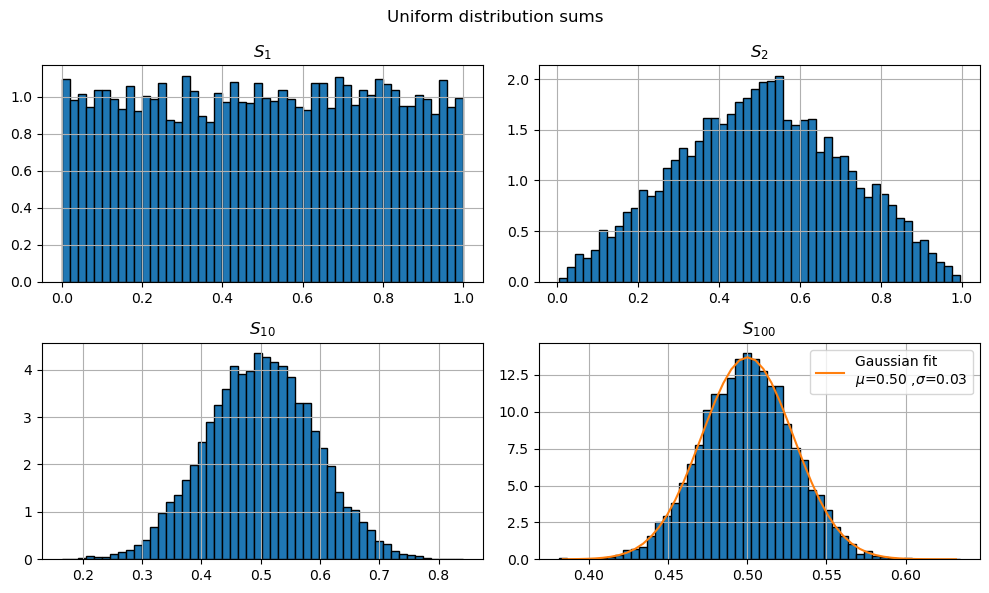

In [59]:
un_N1=pd.read_csv('data/unif_N1.csv')
un_N2=pd.read_csv('data/unif_N2.csv')
un_N10=pd.read_csv('data/unif_N10.csv')
un_N100=pd.read_csv('data/unif_N100.csv')

fig, ax = plt.subplots(2, 2, figsize=(10,6))
fig.suptitle('Uniform distribution sums')


ax[0, 0].hist(un_N1.data,  bins=50, density=True, edgecolor='black', linewidth=1)
ax[0, 0].set_title('$S_1$')

ax[0, 1].hist(un_N2.data,  bins=50, density=True, edgecolor='black', linewidth=1)
ax[0, 1].set_title('$S_2$')

ax[1, 0].hist(un_N10.data, bins=50, density=True, edgecolor='black', linewidth=1)
ax[1, 0].set_title('$S_{10}$')

ax[1, 1].hist(un_N100.data, bins=50, density=True, edgecolor='black', linewidth=1)
ax[1, 1].set_title('$S_{100}$')


y, bins = np.histogram(un_N100.data, bins=50, density=True)
xc=[0.5*(bins[k]+bins[k+1]) for k in range(len(bins)-1)]

popt, pcov = curve_fit(gaussian, xc, y)
ax[1, 1].plot(xc, gaussian(xc, popt[0], popt[1]), label=f'Gaussian fit \n$\mu$={"%.2f"%popt[0]} ,$\sigma$={"%.2f"%popt[1]}')
ax[1, 1].legend()

for k in [0,1]:
    for j  in [0,1]:
        ax[k,j].grid(True)

plt.tight_layout()
plt.show()

## Cauchy-Lorentz

Below the implementation of the Chaucy-Lorentz generator
```C++
double RandomMod::CauchyLorentz(double mu, double gamma)
{
	double y=Rannyu();
	return mu+gamma*(tan(M_PI*(y-0.5)));
}
```

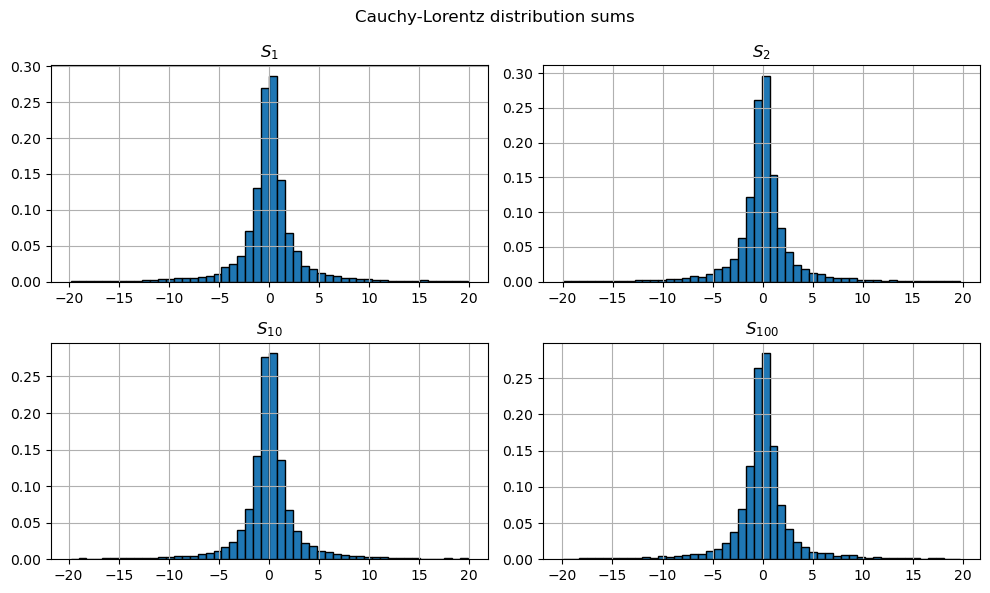

In [60]:
cl_N1=pd.read_csv('data/cauchy_N1.csv')
cl_N2=pd.read_csv('data/cauchy_N2.csv')
cl_N10=pd.read_csv('data/cauchy_N10.csv')
cl_N100=pd.read_csv('data/cauchy_N100.csv')


fig, ax = plt.subplots(2, 2, figsize=(10,6))
fig.suptitle('Cauchy-Lorentz distribution sums')


ax[0, 0].hist(cl_N1.loc[(cl_N1.data<20) ].loc[ (cl_N1.data>-20)].data,   label='1', bins=50, density=True, edgecolor='black', linewidth=1)
ax[0, 0].set_title('$S_1$')

ax[0, 1].hist(cl_N2.loc[cl_N2.data<20].loc[cl_N2.data>-20].data,   label='2', bins=50, density=True, edgecolor='black', linewidth=1)
ax[0, 1].set_title('$S_2$')

ax[1, 0].hist(cl_N10.loc[cl_N10.data<20].loc[cl_N10.data>-20].data,  label='10', bins=50,  density=True, edgecolor='black', linewidth=1)
ax[1, 0].set_title('$S_{10}$')

ax[1, 1].hist(cl_N100.loc[cl_N100.data<20].loc[cl_N100.data>-20].data, label='100', bins=50, density=True, edgecolor='black', linewidth=1)
ax[1, 1].set_title('$S_{100}$')

for k in [0,1]:
    for j  in [0,1]:
        ax[k,j].grid(True)

plt.tight_layout()
plt.show()

dire qualcosa sul fatto che cauchy ha media e varianza non def quindi no clt|

### Exercise 01.3

To simulate the needle on the plane i generated a point following a uniform distribution in [0, d). 

In fact using parallel lines at constant distance d divide the plane in periodics strips so it's enough to generate the first point inside the strip [0, d).

After i generated (using again a uniform distribution) 2 values `x_dir` and `y_dir` $\in [-1,1)$ and used the projector $\frac{x\_dir}{\sqrt{(x\_dir^2 + y\_dir^2 )}}$ to compute the projection $x_1$ of the needle along the x-axis. 

If $x_1>d$ or $x_1<0$ then the needle have an intersection with the lines.

I used 100 blocks with 100 throws per block to estimate the intersection-success rate (for every block) and produce one $\pi$ estimation per block.

After i maded a progressive average and the variance calculation on the blocks values.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

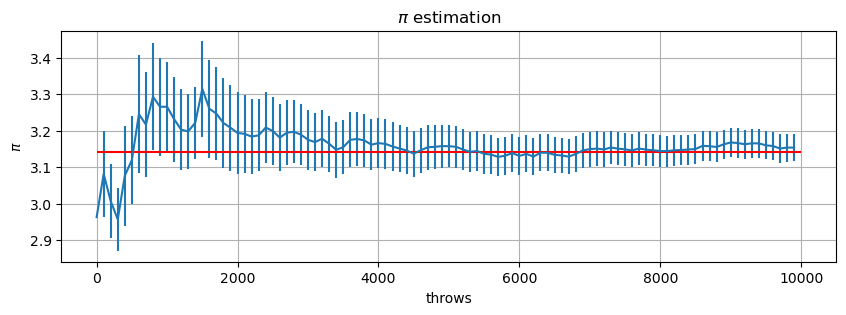

In [ ]:
bf = pd.read_csv('data/prob_buffon.csv')

plt.figure(figsize=(10,3))
plt.title('$\pi$ estimation')
plt.errorbar(bf.throws, bf.avg, yerr=bf.err)
plt.hlines(np.pi, 0, 10000, color='r')
plt.grid()
plt.ylabel('$\pi$')
plt.xlabel('throws')

plt.show()